In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import utils

In [2]:
# dates period
dates_start = "2022-01-01"
dates_end = "2025-01-01"
# some global initialization
rng = np.random.default_rng()
sns.set_theme()

In [3]:
# read all symbols in the SP500 index
# https://github.com/datasets/s-and-p-500-companies/blob/main/data/constituents.csv
sp500 = pd.read_csv("sp500.csv")
symbols = sp500.loc[:, 'Symbol']
symbols.head()

0     MMM
1     AOS
2     ABT
3    ABBV
4     ACN
Name: Symbol, dtype: object

In [4]:
# select the symbols satisfying the condition of the exercise
# TODO: it was supposed to be first letter of my name, but there are only 7
#       companies starting with 'J'
potential_symbols = symbols.loc[symbols.str[0] == 'K']
potential_symbols

85      KMX
112      KO
267       K
268    KVUE
269     KDP
270     KEY
271    KEYS
272     KMB
273     KIM
274     KMI
275     KKR
276    KLAC
277     KHC
278      KR
Name: Symbol, dtype: object

In [5]:
# the symbols have been randomized and then hard coded for consistency
#selected_symbols = rng.choice(potential_symbols, size=10, replace=False)
selected_symbols = ['KDP', 'KKR', 'KIM', 'K', 'KMI', 'KMX', 'KO', 'KEY', 'KR', 'KMB']
selected_symbols = np.array(selected_symbols)
selected_symbols

array(['KDP', 'KKR', 'KIM', 'K', 'KMI', 'KMX', 'KO', 'KEY', 'KR', 'KMB'],
      dtype='<U3')

In [6]:
# download the prices from Yahoo!
tickers = yf.Tickers(" ".join(selected_symbols))
prices = tickers.history(start=dates_start, end=dates_end, period=None, auto_adjust=False)

[*********************100%***********************]  10 of 10 completed


In [7]:
prices.head()

Price       Adj Close                                                          \
Ticker              K        KDP        KEY        KIM        KKR         KMB   
Date                                                                            
2022-01-03  52.895729  33.169426  19.195246  20.473074  71.031303  122.714249   
2022-01-04  53.410950  33.666378  20.204666  21.014469  71.794548  123.377693   
2022-01-05  53.705357  33.628239  20.082558  20.622999  66.644981  124.118645   
2022-01-06  53.942516  33.991486  21.108261  20.756266  68.200485  123.308777   
2022-01-07  54.465908  33.873432  21.450163  20.614672  67.147377  123.842957   

Price                                                    ...   Volume  \
Ticker            KMI         KMX         KO         KR  ...        K   
Date                                                     ...            
2022-01-03  13.034691  127.010002  52.627056  41.449417  ...  1773721   
2022-01-04  13.218055  123.860001  53.505650  42.348282  ...  2338208   
2022-01-05  13.289805  119.349998  53.949394  42.935318  ...  2920669   
2022-01-06  13.568837  119.099998  53.665405  43.219658  ...  2144002   
2022-01-07  13.768144  121.080002  53.541157  44.136879  ...  2621641   

Price                                                                        \
Ticker          KDP       KEY      KIM      KKR      KMB       KMI      KMX   
Date                                                                          
2022-01-03  3508900   6834300  3482400  2061700  1994200  14468600  1031500   
2022-01-04  5305600   8397900  2962700  5905500  2027100  16821400  1568200   
2022-01-05  5777400  10080400  3457800  6245900  1935600  20913100  1198900   
2022-01-06  6505000   9425800  3214700  4383300  1692700  13691100  1159200   
2022-01-07  4939200  11174500  4477100  2937600  1305300  17813800  2329400   

Price                           
Ticker            KO        KR  
Date                            
2022-01-03  20187300   6024700  
2022-01-04  26141600  10378100  
2022-01-05  22507300   8367700  
2022-01-06  17902300   7115600  
2022-01-07  12307900   8672700  

[5 rows x 80 columns]

In [8]:
# we are only interested in adjusted close prices
close_prices = prices.loc[:, "Adj Close"]
close_prices.head()

Ticker,K,KDP,KEY,KIM,KKR,KMB,KMI,KMX,KO,KR
Date,,,,,,,,,,
2022-01-03,52.895729,33.169426,19.195246,20.473074,71.031303,122.714249,13.034691,127.010002,52.627056,41.449417
2022-01-04,53.410950,33.666378,20.204666,21.014469,71.794548,123.377693,13.218055,123.860001,53.505650,42.348282
2022-01-05,53.705357,33.628239,20.082558,20.622999,66.644981,124.118645,13.289805,119.349998,53.949394,42.935318
2022-01-06,53.942516,33.991486,21.108261,20.756266,68.200485,123.308777,13.568837,119.099998,53.665405,43.219658
2022-01-07,54.465908,33.873432,21.450163,20.614672,67.147377,123.842957,13.768144,121.080002,53.541157,44.136879


In [9]:
# calculate simple returns
returns = utils.simple_returns_dataframe(close_prices)
returns.head()

Ticker,K,KDP,KEY,KIM,KKR,KMB,KMI,KMX,KO,KR
Date,,,,,,,,,,
2022-01-04,0.009740,0.014982,0.052587,0.026444,0.010745,0.005406,0.014067,-0.024801,0.016695,0.021686
2022-01-05,0.005512,-0.001133,-0.006044,-0.018629,-0.071726,0.006006,0.005428,-0.036412,0.008293,0.013862
2022-01-06,0.004416,0.010802,0.051074,0.006462,0.023340,-0.006525,0.020996,-0.002095,-0.005264,0.006623
2022-01-07,0.009703,-0.003473,0.016198,-0.006822,-0.015441,0.004332,0.014689,0.016625,-0.002315,0.021222
2022-01-10,0.005706,0.000268,-0.000759,0.015354,-0.002734,0.005913,0.009265,-0.019904,0.001658,0.020366


In [10]:
# in order work with seaborn FacetGrid plotting we need to turn the returns
# into a long form dataframe, that is each row represents a different observation
# and each column a separate variable (in our dase those are 'Date', 'Ticker' and 'Return')
returns_long_form = returns.stack().reset_index().rename(columns={0: "Return"})
returns_long_form.head()

,Date,Ticker,Return
0,2022-01-04,K,0.009740
1,2022-01-04,KDP,0.014982
2,2022-01-04,KEY,0.052587
3,2022-01-04,KIM,0.026444
4,2022-01-04,KKR,0.010745


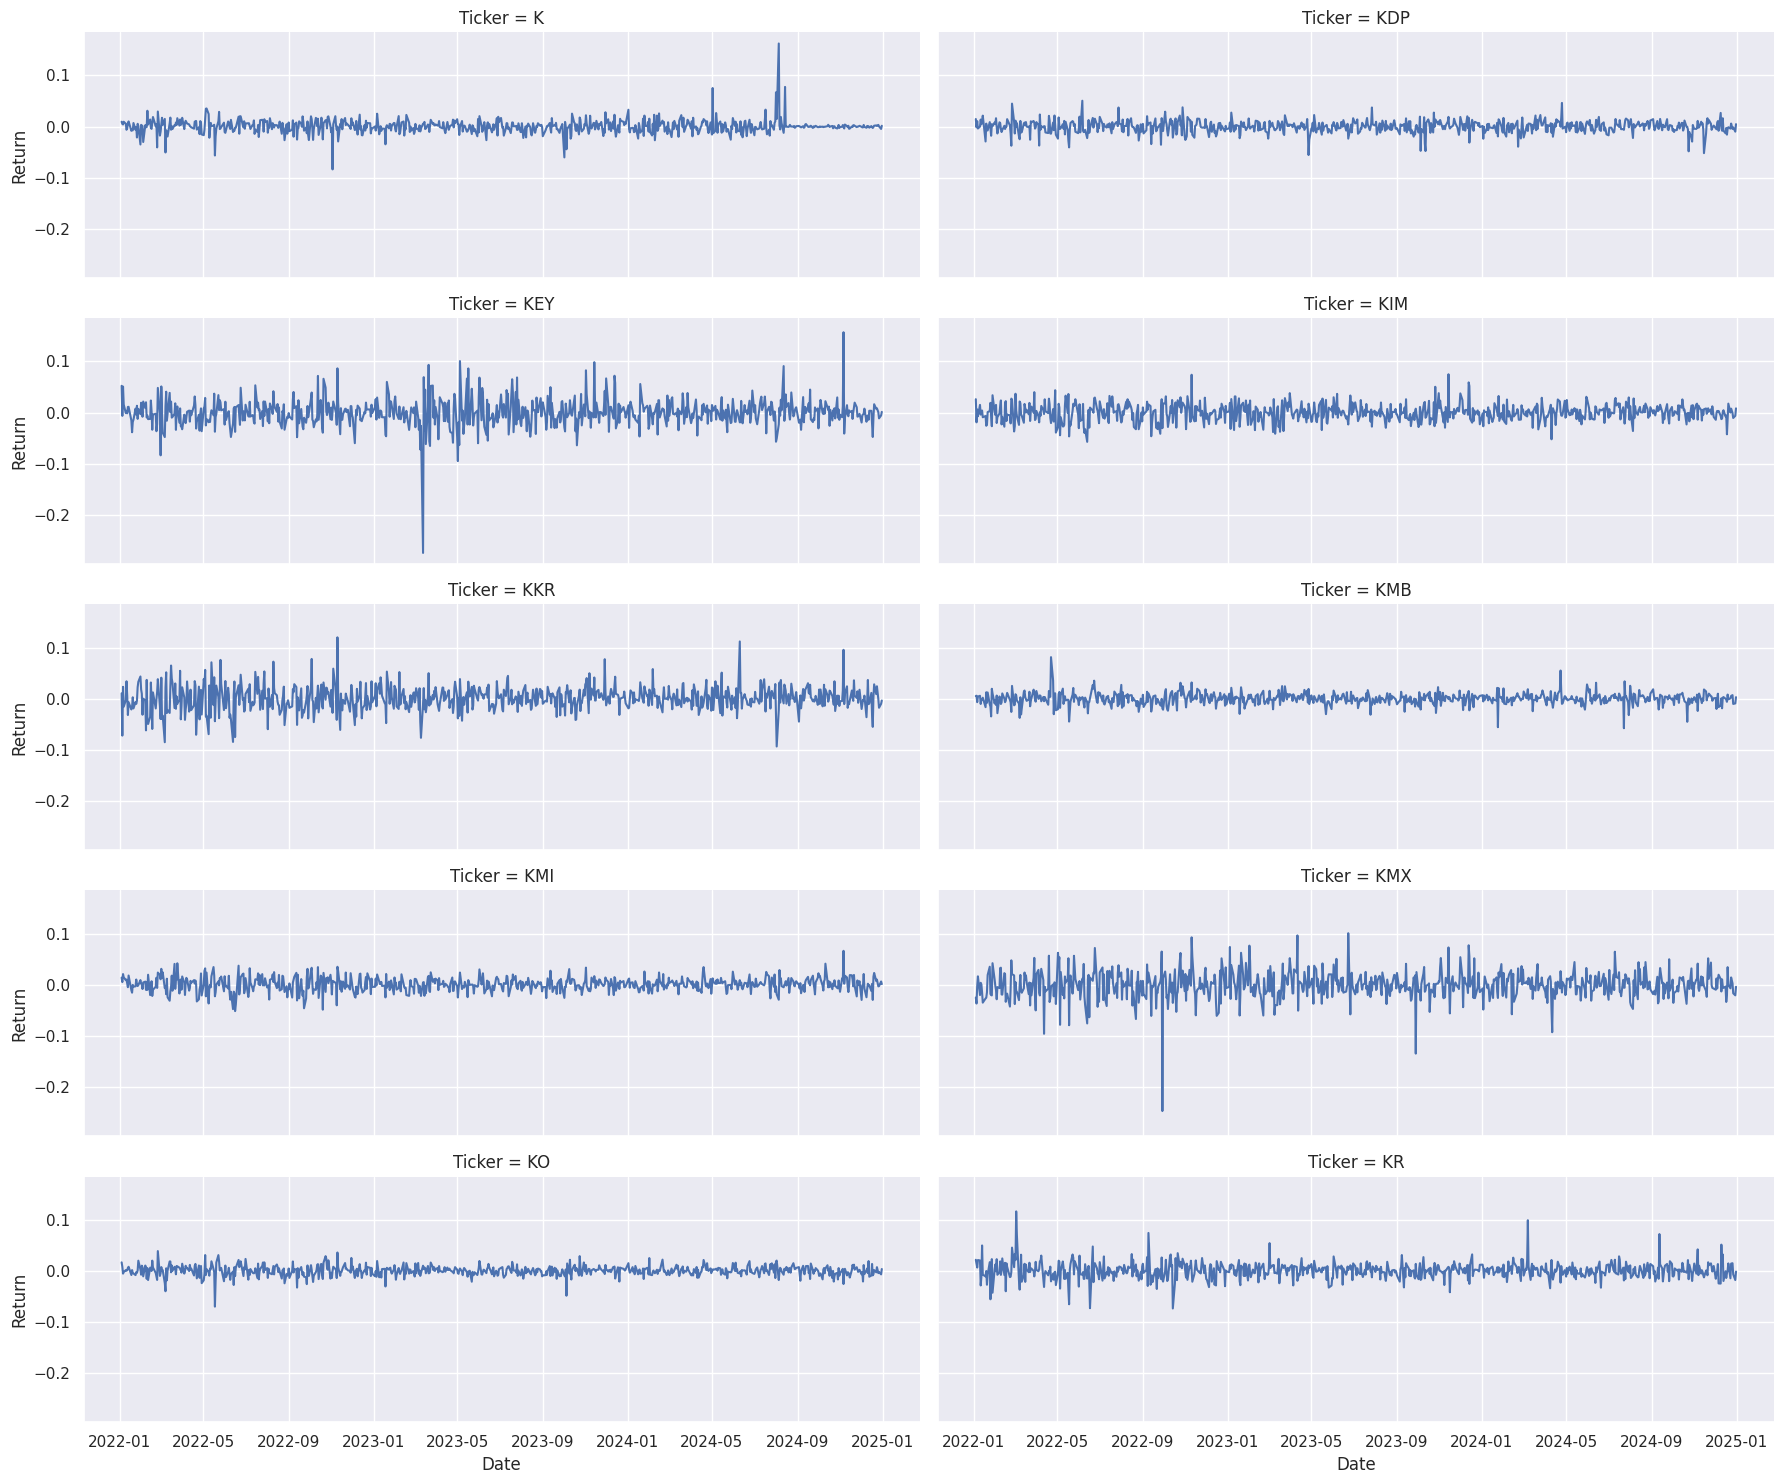

In [11]:
# plot of the simple returns
g = sns.FacetGrid(returns_long_form, col='Ticker', col_wrap=2, aspect=3)
g.map_dataframe(sns.lineplot, x='Date', y='Return')
plt.show()

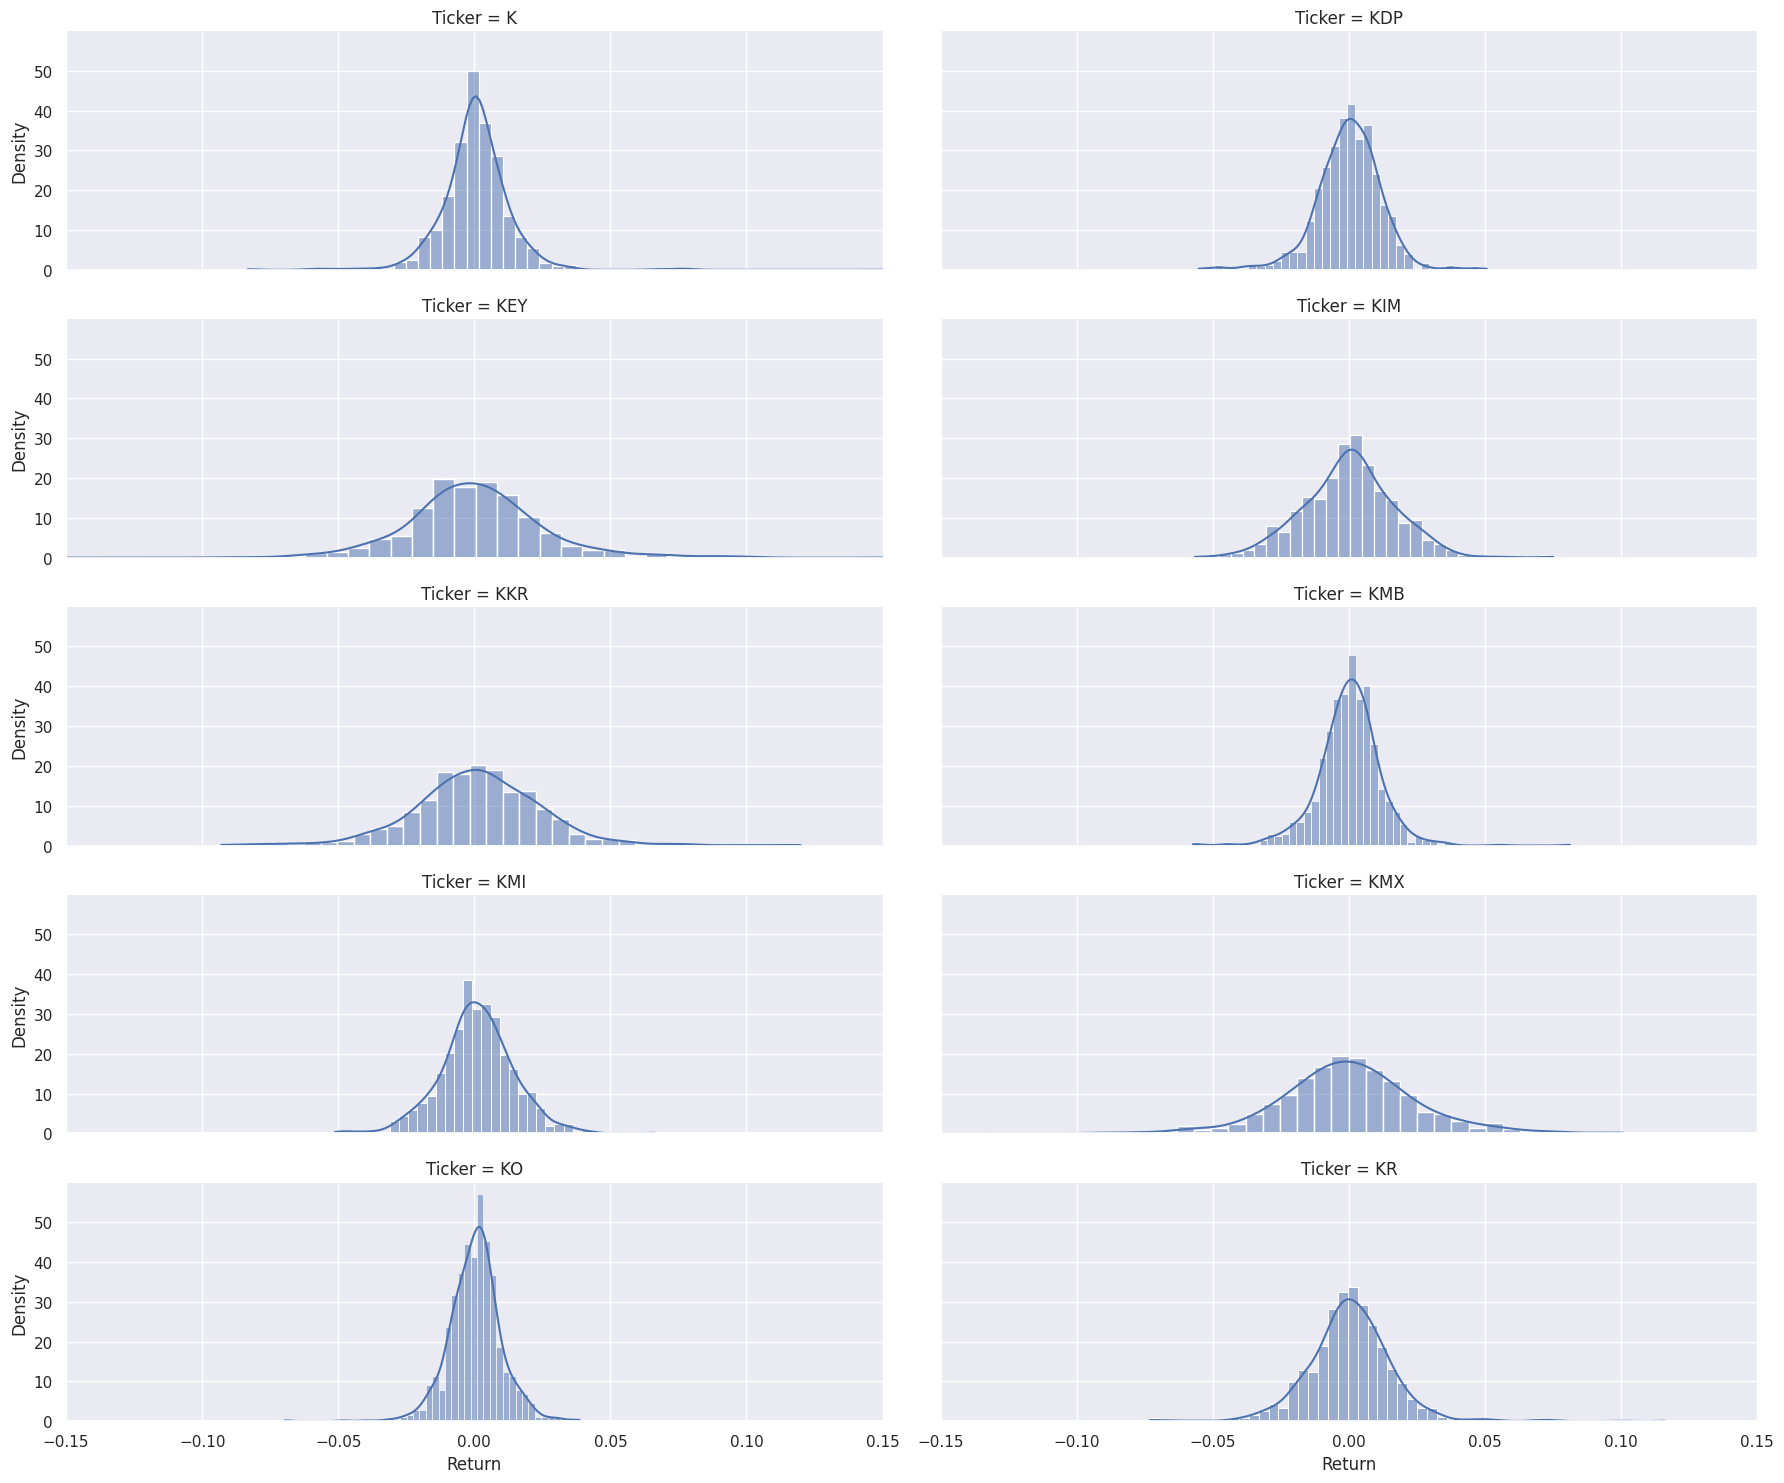

In [12]:
# plot of the histograms and kernel density estimates
g = sns.FacetGrid(returns_long_form, col='Ticker', col_wrap=2, aspect=3, xlim=[-0.15, 0.15])
g.map_dataframe(sns.histplot, 'Return', kde=True, bins='auto', stat='density')
plt.show()

In [13]:
# base characteristics
returns.describe()

Ticker,K,KDP,KEY,KIM,KKR,KMB,KMI,KMX,KO,KR
count,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000
mean,0.000622,-0.000012,0.000163,0.000258,0.001256,0.000102,0.001023,-0.000213,0.000233,0.000621
std,0.013734,0.011886,0.027166,0.016898,0.024038,0.011693,0.013570,0.026994,0.009839,0.016241
min,-0.083223,-0.055211,-0.273308,-0.056659,-0.092944,-0.057305,-0.051136,-0.246008,-0.069626,-0.073223
25%,-0.005152,-0.006598,-0.013536,-0.009834,-0.012262,-0.005995,-0.006413,-0.014279,-0.005277,-0.007712
50%,0.000495,0.000279,-0.000609,0.000503,0.001245,0.000564,0.001012,-0.000529,0.000705,0.000444
75%,0.006749,0.007301,0.012874,0.010394,0.015819,0.006500,0.009045,0.013998,0.005645,0.009046
max,0.162274,0.050673,0.157010,0.075085,0.119873,0.081265,0.066370,0.100741,0.038671,0.116062


In [14]:
returns_long_form.head()

,Date,Ticker,Return
0,2022-01-04,K,0.009740
1,2022-01-04,KDP,0.014982
2,2022-01-04,KEY,0.052587
3,2022-01-04,KIM,0.026444
4,2022-01-04,KKR,0.010745


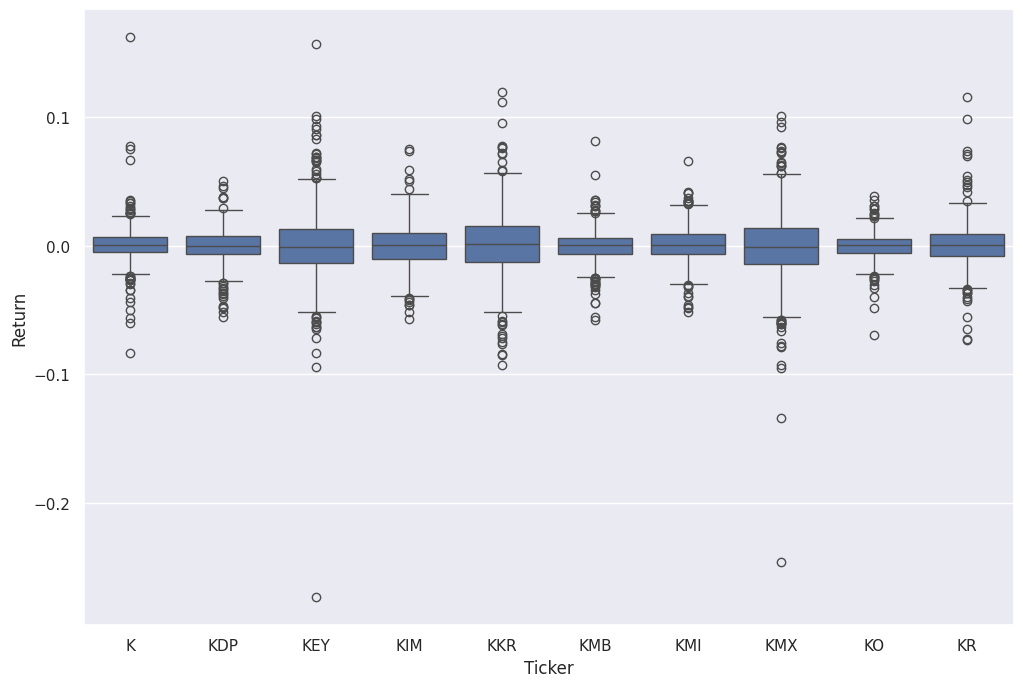

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(returns_long_form, x='Ticker', y='Return', ax=ax)
plt.show()

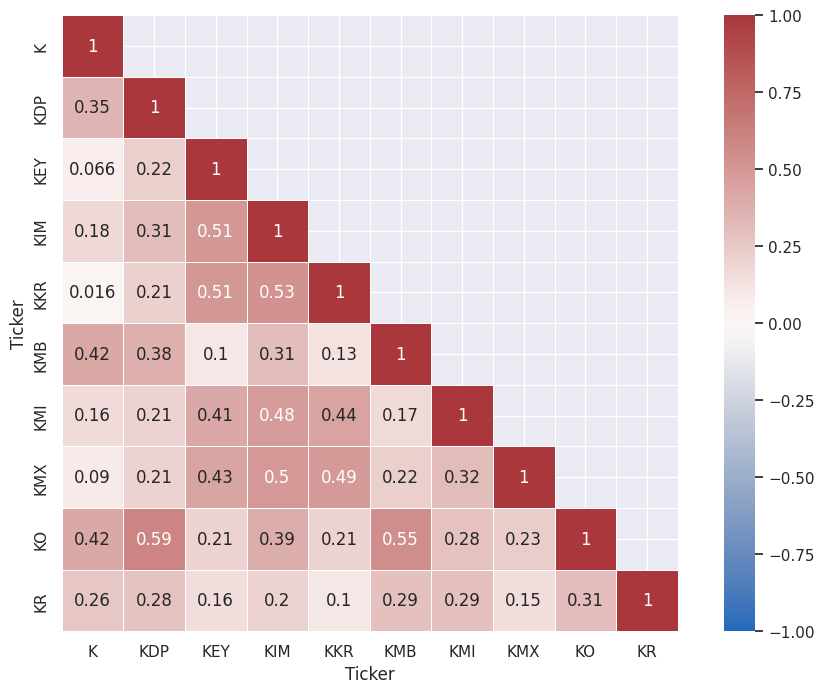

In [16]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, ax=ax, vmin=-1, vmax=1, square=True, mask=np.triu(np.ones_like(corr), k=1), linewidth=0.5, cmap=sns.color_palette('vlag', as_cmap=True))
plt.show()

In [17]:
k_fit = sp.stats.norm.fit(returns['K'])

In [18]:
k_fit

(np.float64(0.000621505383799381), np.float64(0.013725040880177581))

In [19]:
f = sp.stats.norm(*k_fit)

In [21]:
sp.stats.normaltest(returns['K'], loc=k_fit[0], scale=k_fit[1])

TypeError: normaltest() got an unexpected keyword argument 'loc'

In [23]:
sp.stats.goodness_of_fit(sp.stats., returns['K'])

GoodnessOfFitResult(fit_result=  params: FitParams(loc=np.float64(0.000621505383799381), scale=np.float64(0.013734175683771329))
 success: True
 message: 'The fit was performed successfully.', statistic=np.float64(18.063011069775484), pvalue=np.float64(0.0001), null_distribution=array([0.26533763, 0.33883439, 0.65555058, ..., 0.37017605, 0.3461616 ,
       0.76880796], shape=(9999,)))